# 01 - Data Exploration

**Q3**: trade an asset or combination of assets from the given global futures/ETFs. This project takes the brief's first suggested angle, momentum/trend-following CTA, which is conventionally run across a broad diversified futures book rather than a small number of markets.

## Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from cta import data

pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (10, 4)

## Universe survey

The futures catalogue contains 94 unique underlying markets, 188 rows, across six classes. Every market appears twice: `&` prefixes a continuous contract and a `_CCB` suffix marks the vendor's back-adjusted version of it, so `&6E` is the raw Euro FX continuous series and `&6E_CCB` its back-adjusted twin.

In [2]:
fut_cat = data.load_futures_catalogue()
fut_cat.groupby(['subtype1'])['symbol'].count().sort_values(ascending=False) // 2  # /2: raw + _CCB rows

subtype1
Agriculture      26
Stock Index      26
Interest Rate    18
Currency          9
Energy            8
Metal             5
Other             2
Name: symbol, dtype: int64

In [3]:
roots = fut_cat[~fut_cat.symbol.str.endswith('_CCB')][['symbol', 'securityname', 'subtype1']]

def survey(root_row):
    sym_ccb = root_row['symbol'] + '_CCB'
    df = data.load_futures(sym_ccb)
    return pd.Series({
        'class': root_row['subtype1'],
        'name': root_row['securityname'],
        'start': df.index.min().date(),
        'end': df.index.max().date(),
        'n_rows': len(df),
        'nulls': df['Close'].isnull().sum(),
    })

universe_survey = roots.apply(survey, axis=1)
universe_survey.index = roots['symbol']
universe_survey.sort_values('start')

,class,name,start,end,n_rows,nulls
symbol,,,,,,
&ZS,Agriculture,Soybean Continuous Contract,1977-11-21,2014-12-31,9353,0
&ZC,Agriculture,Corn Continuous Contract,1978-01-04,2014-12-31,9324,0
&ZW,Agriculture,Chicago SRW Wheat Continuous Contract,1978-01-05,2014-12-31,9323,0
&ZL,Agriculture,Soybean Oil Continuous Contract,1978-01-17,2014-12-31,9315,0
&ZM,Agriculture,Soybean Meal Continuous Contract,1978-01-25,2014-12-31,9309,0
&ZB,Interest Rate,U.S. T-Bond Continuous Contract,1978-03-10,2014-12-31,9268,0
&GC,Metal,Gold Continuous Contract,1978-03-30,2014-12-31,9238,0
&ZO,Agriculture,Oats Continuous Contract,1978-04-26,2014-12-31,9246,0
&HG,Metal,Copper Continuous Contract,1978-04-27,2014-12-31,9218,0


Every one of the 94 markets ends on 2014-12-30 or 2014-12-31. This is a dataset-wide cutoff rather than a property of FX or bonds specifically, so no recent-years out-of-sample period is available and the walk-forward split has to be carved out of history.

## Roll-adjustment check, at scale

The dataset's back-adjustment is a difference adjustment, which can push older back-adjusted prices non-positive. This section measures how pervasive that is across 86 markets rather than 15, and whether it persists into the 2005-2014 history used for training and testing.

---

> **Correction.** This section concludes that the raw series should be used and `_CCB`
> avoided. That conclusion is wrong, and it inverted the project's headline result until
> an audit caught it. The premise holds: `_CCB` levels do go non-positive for 14 of 94
> markets, so percentage returns on them are unsafe. The error is inferring that raw
> levels are therefore safe. A raw continuous contract splices delivery months, so
> `pct_change()` books the calendar spread at each roll as tradeable P&L, which an
> always-long benchmark harvests and a long/short book pays. The correct construction is
> the back-adjusted price difference over the raw previous close
> (`cta.indicators.held_contract_returns`). Diagnosis and evidence in
> `02_strategy_research.ipynb` Part 2.

In [4]:
window = slice('2005-01-01', '2014-12-31')

def window_check(symbol):
    df = data.load_futures(symbol + '_CCB')
    c = df.loc[window, 'Close']
    return pd.Series({'n_in_window': len(c), 'min_close': c.min() if len(c) else np.nan,
                       'any_nonpositive': bool((c <= 0).any())})

window_survey = roots['symbol'].apply(window_check)
window_survey.index = roots['symbol']
bad = window_survey[window_survey.any_nonpositive]
print(f'{len(bad)} of {len(window_survey)} markets go non-positive on back-adjusted Close within 2005-2014 alone:')
bad.join(roots.set_index('symbol')[['subtype1']])

14 of 94 markets go non-positive on back-adjusted Close within 2005-2014 alone:


,n_in_window,min_close,any_nonpositive,subtype1
symbol,,,,
&CT,2515,-42.0200,True,Agriculture
&DC,2508,-5.9600,True,Agriculture
&GAS,2575,-503.7500,True,Energy
&HE,2519,-2.8000,True,Agriculture
&HO,2518,-1.7988,True,Energy
&HTW,2469,-109.8500,True,Stock Index
&LBS,2519,-757.6000,True,Agriculture
&LSU,2526,-539.9000,True,Agriculture
&OJ,2515,-93.2000,True,Agriculture


The issue is not marginal. 14 markets, mostly agriculture and energy, which carry large roll costs from contango and backwardation, go non-positive on the back-adjusted close within a recent 10-year window rather than only decades back. Percentage returns are undefined or meaningless there.

So, use price differences normalised by a rolling realised-volatility estimate, rather than percentage returns, as the return and signal unit across the universe. This is standard practice for diversified futures trend-following (e.g. Carver's *Systematic Trading*) because a price difference is well-defined regardless of level, and because it allows an E-mini S&P point move and a Corn cents-per-bushel move to be compared. Demonstrated below.

## Curated universe

From the 94 markets, drop:

- The 8 starting after 2004-12-31 (`&6N`, `&EUA`, `&FDAX9`, `&FESX9`, `&FGBX`, `&FTDX`, `&RB`, `&WBS`), too little history before a 2010-2014 OOS window to train on.
- 2 redundant ASX SPI 200 contract variants (`&YAP4`, `&YAP10`), the same underlying as `&YAP`, kept once.

84 markets remain, all with continuous data from on or before 2004-12-31 through 2014-12-31/30.

**Update from `02_strategy_research.ipynb`**: this list still includes markets too illiquid for vol-scaled position sizing. `&YIB` had a 163-consecutive-day run of an unchanged price, which collapsed its 60-day realised vol to ~1e-10 and expanded position sizing to billions the moment the price moved again, producing a multi-million-percent single-day return. `src/cta/data.py`'s `curated_futures_universe()` now also screens out any market with a stale-price run ≥20 trading days, dropping `&YIB`, `&AFB`, `&ZQ` and `&AWM`, plus three money-market rate futures (`&BAX`, `&LEU`, `&YIR`) that are not duration instruments, 77 instruments rather than 84. That function, not the inline list built in this notebook, is the canonical universe.

In [5]:
late_starters = {'&6N', '&EUA', '&FDAX9', '&FESX9', '&FGBX', '&FTDX', '&RB', '&WBS'}
redundant = {'&YAP4', '&YAP10'}
excluded = late_starters | redundant

UNIVERSE = sorted(set(roots['symbol']) - excluded)
print(f'{len(UNIVERSE)} instruments')
roots.set_index('symbol').loc[UNIVERSE].groupby('subtype1').size().sort_values(ascending=False)

84 instruments


subtype1
Agriculture      26
Stock Index      21
Interest Rate    17
Currency          8
Energy            6
Metal             5
Other             1
dtype: int64

## Returns methodology demonstration

One instrument per asset class: EUR FX, Gold, 10Y UST, E-mini S&P 500, Crude Oil, Corn. Raw price level, price-difference return and vol-normalised return are compared. Only the third column is comparable across instruments, since a Corn cents move and an E-mini point move are different units.

In [ ]:
REPRESENTATIVES = {'&6E': 'EUR FX', '&GC': 'Gold', '&ZN': '10Y UST',
                    '&ES': 'E-mini S&P 500', '&CL': 'Crude Oil', '&ZC': 'Corn'}

# Compute diff/rolling-vol per instrument on its OWN native calendar before
# combining - combining first (union of all 6 calendars) then rolling would let
# a single holiday specific to one instrument (e.g. Columbus Day for bond futures,
# Thanksgiving Friday for CME metals/energy) poison the entire next ~60-row
# window for that column, turning one missing day into ~3 months of blank output.
diffs, vols, vol_adjs = {}, {}, {}
for sym, label in REPRESENTATIVES.items():
    s = data.load_futures(sym + '_CCB').loc[window, 'Close'].dropna()
    d = s.diff()
    v = d.rolling(60).std()
    diffs[label], vols[label], vol_adjs[label] = d, v, d / v

price_diff = pd.DataFrame(diffs)
roll_vol = pd.DataFrame(vols)
vol_adj_return = pd.DataFrame(vol_adjs).dropna(how='all')

vol_adj_return.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
EUR FX,-0.005676,1.006136,-5.344083,3.533293
Gold,0.045191,1.032313,-6.139655,4.423892
10Y UST,0.044319,1.007389,-4.217570,4.510421
E-mini S&P 500,0.037322,1.033993,-5.877465,3.993207
Crude Oil,-0.007673,1.017234,-4.932611,4.379267
Corn,0.007551,1.028405,-4.873488,4.245798


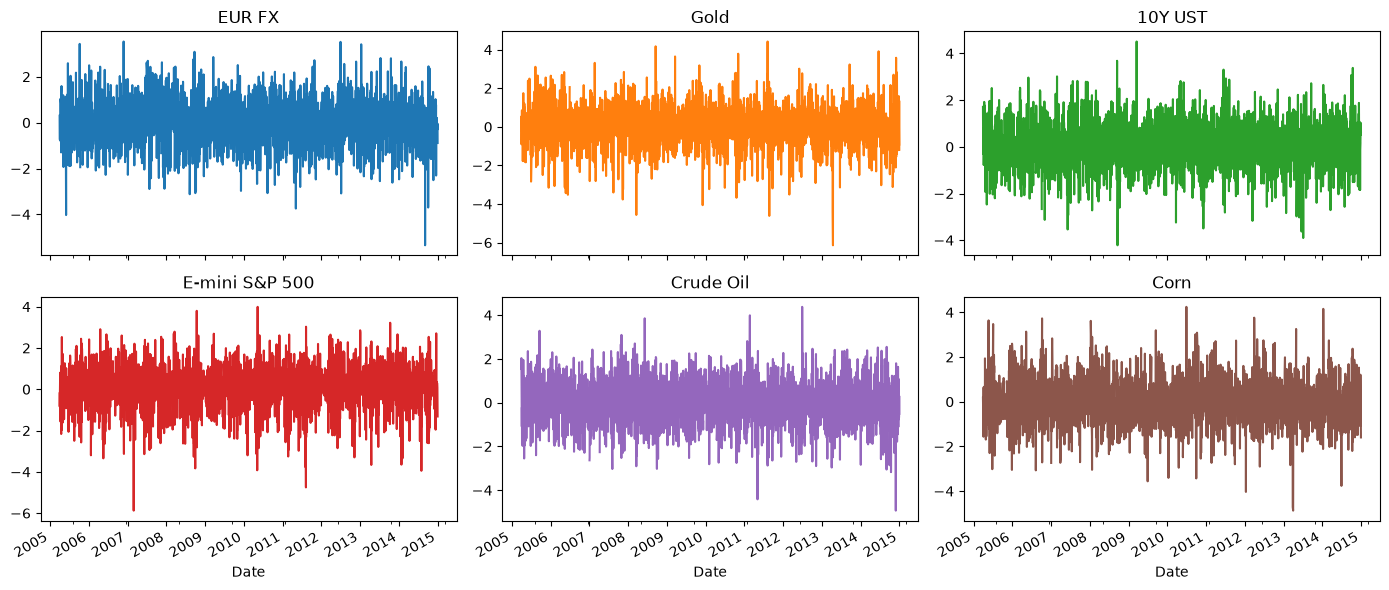

In [7]:
vol_adj_return.plot(subplots=True, layout=(2, 3), figsize=(14, 6), legend=False,
                     title=list(vol_adj_return.columns))
plt.tight_layout()
plt.show()

## Volatility clustering

60-day rolling volatility for the same six representatives. Three points were checked:

1. The lower-amplitude noise across 2005-2007, visible in `vol_adj_return` above, is real. Realised annualised volatility was 1.5-3× lower across every one of these markets before the 2008 financial crisis, EUR FX ~6-8% against ~10-12% after, E-mini S&P ~9-15% against 40%+ in 2008 alone, the pre-GFC Great Moderation.
2. A blank stretch spanning ~2005-2008 was a bug, since fixed. `closes` originally combined all six instruments into one table via a union of their trading calendars, so a holiday specific to one instrument (Columbus Day for bond futures, Thanksgiving Friday for CME metals and energy) produced a shared row with that one column NaN. `.rolling(60).std()` requires the full 60-row window non-null by default, so one missing day invalidated the next ~60 rows of output for that column, and a blanket `.dropna()` across all six columns then deleted that date for all six, which is why the gap appeared simultaneously across every line. Fixed below by computing each instrument's difference and rolling vol on its own native calendar before combining.
3. The raw-unit scale mismatch, EUR FX ~0.003-0.018 against Gold ~2.6-35.7 in price-difference units, requires per-instrument normalisation before plotting on a shared axis.

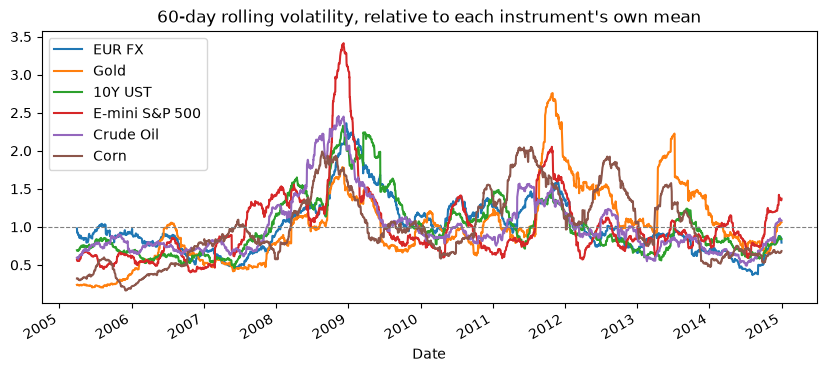

In [8]:
# Raw price-difference-unit roll_vol isn't comparable across instruments (EUR FX ~0.01 vs Gold ~20) -- normalize each to its own mean so relative calm/turbulent regimes are visible on a shared axis.
(roll_vol / roll_vol.mean()).plot(
    title='60-day rolling volatility, relative to each instrument\'s own mean')
plt.axhline(1.0, color='grey', linewidth=0.8, linestyle='--')
plt.show()

## Cross-asset-class correlations

The diversification question relevant to a trend-following book is whether different asset classes move independently. Measured on vol-normalised daily returns for one representative per class over the shared 2005-2014 window.

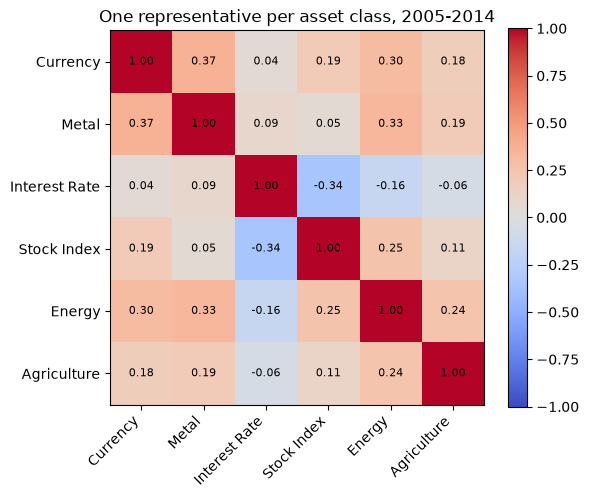

In [9]:
REPRESENTATIVES_BY_CLASS = {
    '&6E': 'Currency', '&GC': 'Metal', '&ZN': 'Interest Rate',
    '&ES': 'Stock Index', '&CL': 'Energy', '&ZC': 'Agriculture',
}

# Same fix as above: per-instrument diff/rolling-vol before combining.
rep_vol_adjs = {}
for sym, label in REPRESENTATIVES_BY_CLASS.items():
    s = data.load_futures(sym + '_CCB').loc[window, 'Close'].dropna()
    d = s.diff()
    rep_vol_adjs[label] = d / d.rolling(60).std()

rep_vol_adj = pd.DataFrame(rep_vol_adjs)
corr = rep_vol_adj.dropna().corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im)
ax.set_title('One representative per asset class, 2005-2014')
plt.tight_layout()
plt.show()

(The full 84×84 pairwise matrix, 80×80 after the later staleness fix, is one line, `closes.corr()` on the curated universe, but is not reproduced here since a matrix of that size is not readable as a heatmap. Per-class representatives capture the diversification structure relevant at the strategy-design stage.)


## Potential fixes

Problems this notebook surfaced, and the fix proposed for each. Later notebooks refer back
to these by number.

1. **Return construction.** Back-adjusted (`_CCB`) levels go non-positive for 14 of 94
   markets, so percentage returns taken on those levels are undefined. Proposed fix: use
   price differences normalised by a rolling realised-volatility estimate.
2. **Universe screening.** 8 markets start after 2004-12-31, too late to train on before a
   2010-2014 out-of-sample window, and 2 are redundant ASX SPI 200 contract variants.
   Proposed fix: drop both groups by rule, leaving 84 markets.
3. **Rolling-window calendar handling.** Combining instruments on a union of trading
   calendars lets one instrument's holiday invalidate roughly 60 rows of every other
   instrument's rolling volatility. Proposed fix: compute each instrument's differences and
   rolling vol on its own native calendar before combining. Applied in this notebook.
4. **Out-of-sample design.** Every series ends 2014-12-31, so no recent data is available to
   hold out. Proposed fix: carve the walk-forward window out of history and reserve
   2010-2014.
5. **Correlation evidence.** Diversification was checked on one representative per asset
   class rather than on the full universe. Proposed fix: confirm at full-universe scale
   during backtesting.

Fix 1 is superseded by the literature pass (`research/literature_notes.md`).
Moskowitz-Ooi-Pedersen and Baltas-Kosowski, whose 71-instrument 1974-2012 universe is close
to this one, splice the most-liquid raw contract and take percentage returns on that spliced
series rather than using a difference-adjusted continuous contract. That convention is
simpler than the price-difference and vol-normalisation workaround proposed above, and it is
the standard in this literature, so it was adopted instead. It was itself replaced by the
held-contract construction in `02_strategy_research.ipynb` Part 2, which is what the project
uses.

Fix 2 is extended in `02_strategy_research.ipynb`, which adds a stale-price screen and drops
three money-market rate futures, taking the universe from 84 markets to 77. Fixes 3 to 5 were
implemented as proposed.
